In [1]:
!pip install biopython pyarrow

In [21]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from Bio import SeqIO
import pandas as pd
import numpy as np

In [ ]:

trainparquet = '../GenDataset/train.parquet'
testparquet = '../GenDataset/test.parquet'

# Lire le fichier parquet
df_train = pd.read_parquet(trainparquet, engine='pyarrow')  
df_test = pd.read_parquet(testparquet, engine='pyarrow')  

# csv_train = 'train.csv'
# csv_test = 'test.csv'
# df_train.to_csv(csv_train, index=False)
# df_test.to_csv(csv_test, index=False)



In [23]:
df_train.head()

,seq,label
0,TTTCTGAATTTTACCAAACTGTAAGTAAATTACGTGGAATATAACA...,0
1,ACTCCAGTTCCTTTGGTCATTTTTTGTTCAGTGAGTTGACAGTAAT...,0
2,CGAACTGAGCTGAACTTTGGATCATCATGCACAGCAGCGCTTTTAC...,0
3,AACATATAAATATAAATTCTAGTGCGCTTCGTTACTACGTTATTCA...,0
4,GCTAAAGATTATAAGTGCATATTGGAACTATTATCAGTGGGAAAAT...,0


In [24]:
df_train['label'].value_counts()

label
0    2592
1    2592
Name: count, dtype: int64

In [25]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

seq      0
label    0
dtype: int64
seq      0
label    0
dtype: int64


In [26]:
# Taille des séquences
df_train['seq_length'] = df_train['seq'].apply(len)
df_train.head()

,seq,label,seq_length
0,TTTCTGAATTTTACCAAACTGTAAGTAAATTACGTGGAATATAACA...,0,2208
1,ACTCCAGTTCCTTTGGTCATTTTTTGTTCAGTGAGTTGACAGTAAT...,0,2238
2,CGAACTGAGCTGAACTTTGGATCATCATGCACAGCAGCGCTTTTAC...,0,2211
3,AACATATAAATATAAATTCTAGTGCGCTTCGTTACTACGTTATTCA...,0,2229
4,GCTAAAGATTATAAGTGCATATTGGAACTATTATCAGTGGGAAAAT...,0,2353


In [27]:
print(df_train[['seq_length']].describe())


        seq_length
count  5184.000000
mean   2116.262731
std     289.428417
min     236.000000
25%    2103.000000
50%    2142.000000
75%    2203.000000
max    3237.000000


<Axes: >

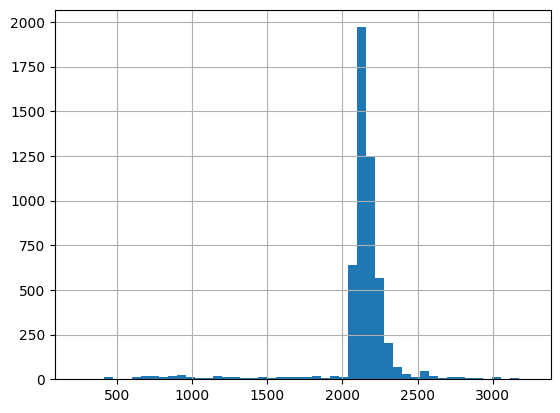

In [28]:
df_train['seq_length'].hist(bins=50)

In [29]:
# Tokenization simple : chaque caractère est un token
# def tokenize_sequence(sequence):
#     return list(sequence)  # Chaque caractère est un token

# df_train['tokens'] = df_train['seq'].apply(tokenize_sequence)
# print(df_train['tokens'].head())


In [30]:
def generate_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# la tokenisation en k-mers
k = 7  
df_train['kmers'] = df_train['seq'].apply(lambda x: generate_kmers(x, k))
df_train['kmers'].head()


0    [TTTCTGA, TTCTGAA, TCTGAAT, CTGAATT, TGAATTT, ...
1    [ACTCCAG, CTCCAGT, TCCAGTT, CCAGTTC, CAGTTCC, ...
2    [CGAACTG, GAACTGA, AACTGAG, ACTGAGC, CTGAGCT, ...
3    [AACATAT, ACATATA, CATATAA, ATATAAA, TATAAAT, ...
4    [GCTAAAG, CTAAAGA, TAAAGAT, AAAGATT, AAGATTA, ...
Name: kmers, dtype: object

In [31]:
df_test['kmers'] = df_test['seq'].apply(lambda x: generate_kmers(x, k))
df_test['kmers'].head()

0    [ACATAAC, CATAACA, ATAACAT, TAACATA, AACATAT, ...
1    [GCCACGC, CCACGCA, CACGCAA, ACGCAAA, CGCAAAA, ...
2    [GCAATTT, CAATTTG, AATTTGG, ATTTGGG, TTTGGGG, ...
3    [ATGCTGC, TGCTGCA, GCTGCAT, CTGCATT, TGCATTT, ...
4    [TTTCTCT, TTCTCTT, TCTCTTT, CTCTTTT, TCTTTTT, ...
Name: kmers, dtype: object

In [32]:

# Préparer les k-mers comme une chaîne de texte
df_train['kmers_str'] = df_train['kmers'].apply(lambda x: ' '.join(x))
df_train['kmers_str'].head()



0    TTTCTGA TTCTGAA TCTGAAT CTGAATT TGAATTT GAATTT...
1    ACTCCAG CTCCAGT TCCAGTT CCAGTTC CAGTTCC AGTTCC...
2    CGAACTG GAACTGA AACTGAG ACTGAGC CTGAGCT TGAGCT...
3    AACATAT ACATATA CATATAA ATATAAA TATAAAT ATAAAT...
4    GCTAAAG CTAAAGA TAAAGAT AAAGATT AAGATTA AGATTA...
Name: kmers_str, dtype: object

In [33]:
df_test['kmers_str'] = df_test['kmers'].apply(lambda x: ' '.join(x))
df_test['kmers_str'].head()

0    ACATAAC CATAACA ATAACAT TAACATA AACATAT ACATAT...
1    GCCACGC CCACGCA CACGCAA ACGCAAA CGCAAAA GCAAAA...
2    GCAATTT CAATTTG AATTTGG ATTTGGG TTTGGGG TTGGGG...
3    ATGCTGC TGCTGCA GCTGCAT CTGCATT TGCATTT GCATTT...
4    TTTCTCT TTCTCTT TCTCTTT CTCTTTT TCTTTTT CTTTTT...
Name: kmers_str, dtype: object

In [34]:
X_train_text = df_train['kmers_str']
y_train = df_train['label']

X_test_text = df_test['kmers_str']
y_test = df_test['label']

In [16]:
# vectorizer = CountVectorizer(ngram_range=(3,6))
vectorizer = CountVectorizer(ngram_range=(4,4))

X_train = vectorizer.fit_transform(X_train_text)

# Transformer les données de test avec le même vectorizer
X_test = vectorizer.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)


(5184, 1029128)
(1730, 1029128)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB(alpha=0.01)
classifier.fit(X_train, y_train)



MultinomialNB(alpha=0.01)

In [18]:
y_pred = classifier.predict(X_test)    

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
print("Confusion matrix for predictions on test DNA sequence\n")
print(confusion_matrix(y_test, y_pred))
print("\n")
print("Classification report for predictions on test DNA sequence\n")
def get_metrics(y_test, y_predicted):
    accuracy = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, average='weighted')
    recall = recall_score(y_test, y_predicted, average='weighted')
    f1 = f1_score(y_test, y_predicted, average='weighted')
    return accuracy, precision, recall, f1
accuracy, precision, recall, f1 = get_metrics(y_test, y_pred)
print("accuracy = %.3f \nprecision = %.3f \nrecall = %.3f \nf1 = %.3f" % (accuracy, precision, recall, f1))

Confusion matrix for predictions on test DNA sequence

[[646 219]
 [235 630]]


Classification report for predictions on test DNA sequence

accuracy = 0.738 
precision = 0.738 
recall = 0.738 
f1 = 0.738


In [20]:
219+235

454

# Optimisation avec optuna

In [ ]:
import optuna
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Charger tes données
X_train_text = df_train['kmers_str']
y_train = df_train['label']

X_test_text = df_test['kmers_str']
y_test = df_test['label']

# Transformer les données avec CountVectorizer
vectorizer = CountVectorizer(ngram_range=(4, 4))  # Utilisation de ngram_range fixe
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Taille X_train:", X_train.shape)
print("Taille X_test:", X_test.shape)

# 1. Définir la fonction objectif pour Optuna
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1.0)  # alpha entre 0.001 et 1.0
    
    # Créer et entraîner le modèle
    classifier = MultinomialNB(alpha=alpha)
    classifier.fit(X_train, y_train)
    
    y_pred = classifier.predict(X_test)
    
    # Évaluer la précision du modèle
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy  



Taille X_train: (5184, 1029128)
Taille X_test: (1730, 1029128)


In [37]:
# 2. Créer une étude Optuna et lancer l'optimisation
study = optuna.create_study(direction='maximize')  # On veut maximiser l'accuracy
study.optimize(objective, n_trials=20)  # Nombre d'itérations pour la recherche d'hyperparamètres

# 3. Afficher les meilleurs résultats
print("Meilleur hyperparamètre alpha trouvé :", study.best_params['alpha'])
print("Meilleure précision obtenue :", study.best_value)


[I 2024-12-10 15:11:56,653] A new study created in memory with name: no-name-350e3416-5a39-4c1e-b7af-86db15c6a6e1
C:\Users\sirou\AppData\Local\Temp\ipykernel_5460\1931457129.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 1.0)  # alpha entre 0.001 et 1.0
[I 2024-12-10 15:11:56,921] Trial 0 finished with value: 0.7375722543352601 and parameters: {'alpha': 0.49897251841073387}. Best is trial 0 with value: 0.7375722543352601.
C:\Users\sirou\AppData\Local\Temp\ipykernel_5460\1931457129.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 1.0)  # alpha entre 0.001 et 1.0
[I 2

Meilleur hyperparamètre alpha trouvé : 0.08157274895209307
Meilleure précision obtenue : 0.7508670520231214


In [38]:

# 4. Réentraîner le modèle final avec le meilleur alpha
best_alpha = study.best_params['alpha']
classifier = MultinomialNB(alpha=best_alpha)
classifier.fit(X_train, y_train)

# Prédiction finale
y_pred = classifier.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)
print("Précision finale avec le meilleur modèle :", final_accuracy)

Précision finale avec le meilleur modèle : 0.7508670520231214


# BOW

In [42]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Vectorisation avec Bag of Words (BOW)
vectorizer_bow = CountVectorizer(ngram_range=(5, 5))  # Par défaut, unigrams seulement (1 mot à la fois)

# Transformer les données
X_train_bow = vectorizer_bow.fit_transform(X_train_text)
X_test_bow = vectorizer_bow.transform(X_test_text)

# Entraîner le modèle avec le meilleur alpha trouvé précédemment
best_alpha = 0.08157274895209307
classifier_bow = MultinomialNB(alpha=best_alpha)
classifier_bow.fit(X_train_bow, y_train)

# Prédictions et évaluation
y_pred_bow = classifier_bow.predict(X_test_bow)
accuracy_bow = accuracy_score(y_test, y_pred_bow)

print("Précision avec Bag of Words :", accuracy_bow)


Précision avec Bag of Words : 0.7358381502890173


# tfidf

In [44]:
def objective_tfidf(trial):
    # Paramètres à optimiser
    ngram_min = trial.suggest_int("ngram_min", 1, 3)
    ngram_max = trial.suggest_int("ngram_max", ngram_min, 4)
    alpha = trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    max_df = trial.suggest_float("max_df", 0.5, 1.0)
    min_df = trial.suggest_int("min_df", 1, 5)

    # Vectorisation TF-IDF
    vectorizer = TfidfVectorizer(ngram_range=(ngram_min, ngram_max), max_df=max_df, min_df=min_df)
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    # Entraînement du modèle
    classifier = MultinomialNB(alpha=alpha)
    classifier.fit(X_train_vec, y_train)
    y_pred = classifier.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Optimisation avec Optuna
study_tfidf = optuna.create_study(direction="maximize")
study_tfidf.optimize(objective_tfidf, n_trials=30)

# Résultats
print("Meilleurs paramètres TF-IDF :", study_tfidf.best_params)
print("Meilleure précision TF-IDF :", study_tfidf.best_value)


[I 2024-12-10 15:36:42,712] A new study created in memory with name: no-name-2eebadb1-6b8d-4e69-9e3e-900d97424284
[I 2024-12-10 15:36:54,540] Trial 0 finished with value: 0.715028901734104 and parameters: {'ngram_min': 1, 'ngram_max': 1, 'alpha': 0.45356091152233563, 'max_df': 0.7420805299059916, 'min_df': 2}. Best is trial 0 with value: 0.715028901734104.
[I 2024-12-10 15:38:12,001] Trial 1 finished with value: 0.7416184971098266 and parameters: {'ngram_min': 1, 'ngram_max': 4, 'alpha': 0.0010428004664230026, 'max_df': 0.9510254336878623, 'min_df': 2}. Best is trial 1 with value: 0.7416184971098266.
[I 2024-12-10 15:38:33,709] Trial 2 finished with value: 0.7144508670520231 and parameters: {'ngram_min': 1, 'ngram_max': 1, 'alpha': 0.004138348760799885, 'max_df': 0.908805164389675, 'min_df': 2}. Best is trial 1 with value: 0.7416184971098266.
[I 2024-12-10 15:40:18,393] Trial 3 finished with value: 0.7335260115606936 and parameters: {'ngram_min': 2, 'ngram_max': 4, 'alpha': 0.132413547

Meilleurs paramètres TF-IDF : {'ngram_min': 2, 'ngram_max': 4, 'alpha': 0.004451380620846229, 'max_df': 0.5749639248192985, 'min_df': 1}
Meilleure précision TF-IDF : 0.7439306358381503
